In [1]:
import os
from moviepy.editor import VideoFileClip
import speech_recognition as sr
import yt_dlp
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# Load API key
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

In [3]:
# Define paths
video_url = "https://www.youtube.com/watch?v=EKm0spFxFG4"
base_output_folder = "./mixed_data"
output_video_path = os.path.join(base_output_folder, "video_data")
output_audio_path = os.path.join(base_output_folder, "audio_output", "output_audio.wav")

In [4]:
# Ensure directories exist
os.makedirs(output_video_path, exist_ok=True)
os.makedirs(os.path.dirname(output_audio_path), exist_ok=True)

In [5]:
# Filepath for downloaded video
filepath = os.path.join(output_video_path, "input_vid.mp4")

In [6]:
def download_video(url, output_path):
    ydl_opts = {
        "format": "best",
        "outtmpl": os.path.join(output_path, "input_vid.mp4"),
    }
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=True)
        metadata = {
            "Author": info.get("uploader"),
            "Title": info.get("title"),
            "Views": info.get("view_count"),
        }
    return metadata

In [7]:

def video_to_images(video_path, output_folder):
    os.makedirs(output_folder, exist_ok=True)  # Ensure output folder exists
    clip = VideoFileClip(video_path)
    clip.write_images_sequence(
        os.path.join(output_folder, "frame%04d.png"), fps=0.2
    )

In [8]:
def video_to_audio(video_path, output_audio_path):
    clip = VideoFileClip(video_path)
    audio = clip.audio
    audio.write_audiofile(output_audio_path)

In [9]:
def audio_to_text(audio_path):
    recognizer = sr.Recognizer()
    audio = sr.AudioFile(audio_path)

    with audio as source:
        audio_data = recognizer.record(source)
        try:
            # Recognize the speech
            text = recognizer.recognize_whisper(audio_data)
            return text
        except sr.UnknownValueError:
            print("Speech recognition could not understand the audio.")
            return None

In [10]:
# Download video
metadata_vid = download_video(video_url, output_video_path)
print("Video Metadata:", metadata_vid)

[youtube] Extracting URL: https://www.youtube.com/watch?v=EKm0spFxFG4
[youtube] EKm0spFxFG4: Downloading webpage
[youtube] EKm0spFxFG4: Downloading tv client config
[youtube] EKm0spFxFG4: Downloading player 91201489
[youtube] EKm0spFxFG4: Downloading tv player API JSON
[youtube] EKm0spFxFG4: Downloading ios player API JSON
[youtube] EKm0spFxFG4: Downloading m3u8 information
[info] EKm0spFxFG4: Downloading 1 format(s): 18
[download] mixed_data\video_data\input_vid.mp4 has already been downloaded
[download] 100% of    5.28MiB
Video Metadata: {'Author': '3-Minute Data Science', 'Title': 'Logistic Regression in 3 Minutes', 'Views': 124671}


In [11]:
# Convert video to images
video_to_images(filepath, base_output_folder)

In [12]:
# Convert video to audio
video_to_audio(filepath, output_audio_path)

MoviePy - Writing audio in ./mixed_data\audio_output\output_audio.wav


MoviePy - Done.


In [13]:
# Convert audio to text
transcribed_text = audio_to_text(output_audio_path)
print("Transcribed Text:", transcribed_text)

Transcribed Text:  Logistic regression is a statistical technique that models the probability and event given one or more independent variables. You'll start with input data that is of any numeric type, but the output variable will be binary, it'll be 0 or 1, indicating a false or true value respectively. You then fit this S-shaped curve called the logistic function to this data. It can then be used to make predictions of probability whether or not an event will happen, such as given so many hours of rain, what is the probability of a flood. Notice how these points can project themselves onto the logistic function, and we can use maximum likelihood estimation to fit the curve, which we'll talk about shortly. Notice that there are these middle points where there is a mix of true and false cases. If these points follow a transitional trend of increasingly showing an event more likely to happen or not happen, you will see that that S-shaped curve will climb or decrease respectively. We ca

In [14]:
text_data = transcribed_text
print(text_data)

 Logistic regression is a statistical technique that models the probability and event given one or more independent variables. You'll start with input data that is of any numeric type, but the output variable will be binary, it'll be 0 or 1, indicating a false or true value respectively. You then fit this S-shaped curve called the logistic function to this data. It can then be used to make predictions of probability whether or not an event will happen, such as given so many hours of rain, what is the probability of a flood. Notice how these points can project themselves onto the logistic function, and we can use maximum likelihood estimation to fit the curve, which we'll talk about shortly. Notice that there are these middle points where there is a mix of true and false cases. If these points follow a transitional trend of increasingly showing an event more likely to happen or not happen, you will see that that S-shaped curve will climb or decrease respectively. We can then leverage it

In [15]:
base_output_folder

'./mixed_data'

In [16]:
with open(base_output_folder + "output_text.txt","w") as file:
    file.write(text_data)
print("Text data saved to file")
file.close()

Text data saved to file


In [17]:
os.remove(output_audio_path)
print("Audio file removed")

Audio file removed


In [18]:
from llama_index.core.indices import MultiModalVectorStoreIndex
from llama_index.core import SimpleDirectoryReader
from llama_index.core import StorageContext
from llama_index.vector_stores.lancedb import LanceDBVectorStore

In [19]:
text_store=LanceDBVectorStore(uri="lancedb",table_name="text_collection")
image_store=LanceDBVectorStore(uri="lancedb",table_name="image_collection")

In [20]:
storage_context = StorageContext.from_defaults(vector_store=text_store,image_store=image_store)

In [21]:
storage_context

StorageContext(docstore=<llama_index.core.storage.docstore.simple_docstore.SimpleDocumentStore object at 0x00000295157E4A90>, index_store=<llama_index.core.storage.index_store.simple_index_store.SimpleIndexStore object at 0x00000295157E4A30>, vector_stores={'default': LanceDBVectorStore(stores_text=True, is_embedding_query=True, flat_metadata=True, uri='lancedb', vector_column_name='vector', nprobes=20, refine_factor=None, text_key='text', doc_id_key='doc_id', api_key=None, region=None, mode='overwrite', query_type='vector', overfetch_factor=1), 'image': LanceDBVectorStore(stores_text=True, is_embedding_query=True, flat_metadata=True, uri='lancedb', vector_column_name='vector', nprobes=20, refine_factor=None, text_key='text', doc_id_key='doc_id', api_key=None, region=None, mode='overwrite', query_type='vector', overfetch_factor=1)}, graph_store=<llama_index.core.graph_stores.simple.SimpleGraphStore object at 0x00000295157E4100>, property_graph_store=None)

In [22]:
base_output_folder

'./mixed_data'

In [23]:
documents=SimpleDirectoryReader(base_output_folder).load_data()

In [24]:
documents

[ImageDocument(id_='3dd711ea-71e9-46ef-9028-5fcaaed1cf38', embedding=None, metadata={'file_path': 'c:\\Users\\vikas\\OneDrive\\Desktop\\Generative-AI-Sunny-Sir\\Multimodal RAG Application Using LanceDB and LlamaIndex for Video Processing\\mixed_data\\frame0000.png', 'file_name': 'frame0000.png', 'file_type': 'image/png', 'file_size': 750, 'creation_date': '2025-03-11', 'last_modified_date': '2025-03-11'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text_resource=MediaResource(embeddings=None, data=None, text='', path=None, url=None, mimetype=None), image_resource=MediaResource(embeddings=None, data=None, text=None, path=WindowsPath('c:/Users/vikas/OneDrive/Desktop/Generative-AI-Sunny-Sir/Multimod

In [25]:
index = MultiModalVectorStoreIndex.from_documents(documents,storage_context=storage_context)

In [26]:
retriever_engine=index.as_retriever(similarity_top_k=1, image_similarity_top_k=5)

In [27]:
from llama_index.core.response.notebook_utils import display_source_node
from llama_index.core.schema import ImageNode

In [28]:
def retrieve(retriever_engine, query_str):
    retrieval_results = retriever_engine.retrieve(query_str)

    retrieved_image = []
    retrieved_text = []
    for res_node in retrieval_results:
        if isinstance(res_node.node, ImageNode):
            retrieved_image.append(res_node.node.metadata["file_path"])
        else:
            display_source_node(res_node, source_length=200)
            retrieved_text.append(res_node.text)

    return retrieved_image, retrieved_text

In [29]:
query="can you tell me what is linear regression? explain equation of the multiple linear regression?"

In [30]:
img,text=retrieve(retriever_engine,query)

In [31]:
from PIL import Image
import matplotlib.pyplot as plt
def plot_images(images_path):
  images_shown = 0
  plt.figure(figsize=(16, 9))
  for img_path in images_path:
        if os.path.isfile(img_path):
            image = Image.open(img_path)

            plt.subplot(2, 3, images_shown + 1)
            plt.imshow(image)
            plt.xticks([])
            plt.yticks([])

            images_shown += 1
            if images_shown >= 5:
                break

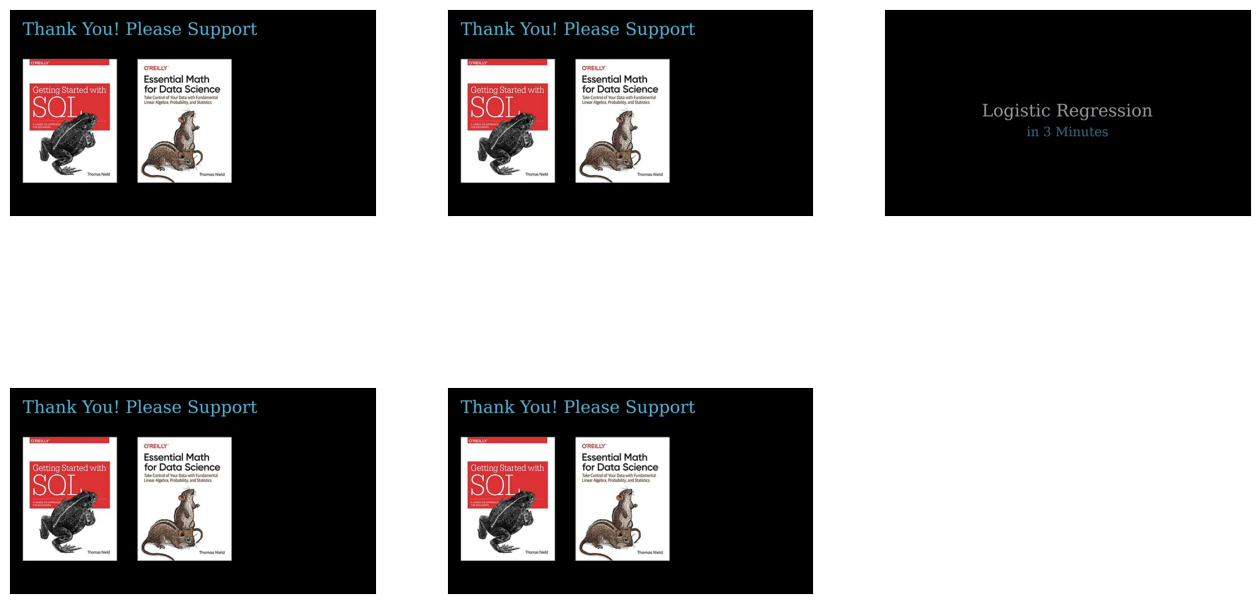

In [32]:
plot_images(img)

In [33]:
qa_tmpl_str=(
    "Based on the provided information, including relevant images and retrieved context from the video, \
    accurately and precisely answer the query without any additional prior knowledge.\n"

    "---------------------\n"
    "Context: {context_str}\n"
    "Metadata for video: {metadata_str} \n"

    "---------------------\n"
    "Query: {query_str}\n"
    "Answer: "
)

In [34]:
img

['c:\\Users\\vikas\\OneDrive\\Desktop\\Generative-AI-Sunny-Sir\\Multimodal RAG Application Using LanceDB and LlamaIndex for Video Processing\\mixed_data\\frame0044.png',
 'c:\\Users\\vikas\\OneDrive\\Desktop\\Generative-AI-Sunny-Sir\\Multimodal RAG Application Using LanceDB and LlamaIndex for Video Processing\\mixed_data\\frame0042.png',
 'c:\\Users\\vikas\\OneDrive\\Desktop\\Generative-AI-Sunny-Sir\\Multimodal RAG Application Using LanceDB and LlamaIndex for Video Processing\\mixed_data\\frame0003.png',
 'c:\\Users\\vikas\\OneDrive\\Desktop\\Generative-AI-Sunny-Sir\\Multimodal RAG Application Using LanceDB and LlamaIndex for Video Processing\\mixed_data\\frame0043.png',
 'c:\\Users\\vikas\\OneDrive\\Desktop\\Generative-AI-Sunny-Sir\\Multimodal RAG Application Using LanceDB and LlamaIndex for Video Processing\\mixed_data\\frame0045.png']

In [35]:
import json
metadata_str=json.dumps(metadata_vid)

In [36]:
query_str="can you tell me what is linear regression and equation of linear regression?"

In [37]:
context_str = "".join(text)

In [38]:
image_documents = SimpleDirectoryReader( input_files=img).load_data()

In [39]:
from llama_index.multi_modal_llms.openai import OpenAIMultiModal

In [40]:
openai_mm_llm = OpenAIMultiModal(model="gpt-4-vision-preview", api_key=OPENAI_API_KEY, max_new_tokens=1500)

In [ ]:
print(result.text)

In [44]:
import json
from llama_index.core import SimpleDirectoryReader
from llama_index.multi_modal_llms.openai import OpenAIMultiModal

# Convert metadata to JSON string
metadata_str = json.dumps(metadata_vid)

# Define query
query_str = "Can you tell me what is linear regression and equation of linear regression?"

# Ensure `text` is correctly formatted
context_str = "".join(text) if isinstance(text, list) else str(text)

# Ensure `img` is a list of image file paths
if not isinstance(img, list):
    raise ValueError("img should be a list of image file paths.")

# Load images using SimpleDirectoryReader
image_documents = SimpleDirectoryReader(input_files=img).load_data()

# Initialize OpenAI multi-modal model (Use `gpt-4-turbo`)
openai_mm_llm = OpenAIMultiModal(model="gpt-4-turbo", api_key=OPENAI_API_KEY, max_new_tokens=1500)

# Format prompt correctly
qa_tmpl_str = (
    "Based on the provided information, including relevant images and retrieved context from the video, "
    "accurately and precisely answer the query without any additional prior knowledge.\n"
    "---------------------\n"
    "Context: {context_str}\n"
    "Metadata for video: {metadata_str} \n"
    "---------------------\n"
    "Query: {query_str}\n"
    "Answer: "
)

# Run OpenAI multi-modal model
try:
    result = openai_mm_llm.complete(
        prompt=qa_tmpl_str.format(
            query_str=query_str,
            metadata_str=metadata_str,
            context_str=context_str  # Now included properly
        ),
        image_documents=image_documents,
    )
    print(result.text)

except Exception as e:
    print(f"Error occurred: {e}")


Linear regression is a statistical method used to model the relationship between a dependent variable and one or more independent variables. The goal is to find a linear equation that best predicts the dependent variable based on the values of the independent variables.

The equation of linear regression is typically written as:
\[ y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \ldots + \beta_nx_n + \epsilon \]
where:
- \( y \) is the dependent variable,
- \( \beta_0 \) is the y-intercept,
- \( \beta_1, \beta_2, \ldots, \beta_n \) are the coefficients of the independent variables \( x_1, x_2, \ldots, x_n \),
- \( \epsilon \) is the error term, accounting for the variability in \( y \) not explained by the independent variables.


In [50]:
print("The End")

The End
